# 📌 Chú thích Hình — Dữ liệu thô 3D (Raw gaze data)

Hình dưới vẽ toàn bộ điểm nhìn thô của 1 file mẫu (`tester01_1.txt`) trong không gian 3 chiều **(X, Y, Vận tốc)**:

- Trục X, Y: tọa độ điểm nhìn trên màn hình, đã chuẩn hóa về khoảng [0, 1].
- Trục Z (V): vận tốc di chuyển của mắt tại điểm đó.
- Tất cả điểm được vẽ **cùng 1 màu đen**, vì ở bước này chưa có bất kỳ phân đoạn/phân loại nào — đây là dữ liệu đầu vào "sạch", trước khi đưa qua pipeline GMM-HMM 2 tầng.

Đang hiển thị: tester01_1.txt (371 samples)


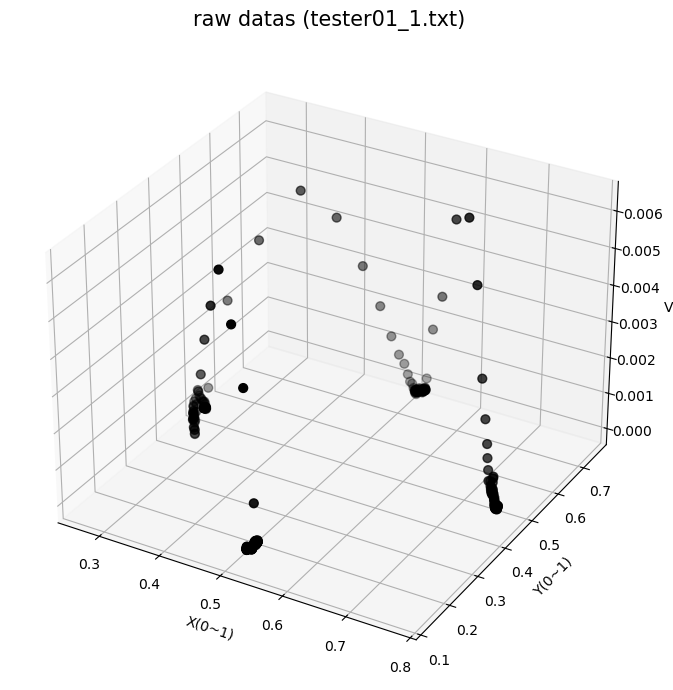

In [56]:
# =======================================================
# CELL 1: HÌNH 1 - DỮ LIỆU THÔ 3D (FILE tester01_1.txt)
# =======================================================
from pathlib import Path

# Đọc trực tiếp file tester01_1.txt
target_file = Path(r"dataset/testdataset/tester01_1.txt")
if not target_file.exists():
    target_file = Path(r"C:\Users\ADMIN\Downloads\eyemovement_update_v1\dataset\testdataset\tester01_1.txt")

sample_features, sample_labels = load_sequence(target_file)
print(f"Đang hiển thị: {target_file.name} ({len(sample_features)} samples)")

# Vẽ Hình 1: Dữ liệu thô ban đầu (màu đen đặc, s=40, depthshade=True)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sample_features[:, 0], sample_features[:, 1], sample_features[:, 2], 
           zdir="z", c="#000000", marker="o", s=40, depthshade=True)

ax.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax.set_title(f"raw datas ({target_file.name})", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

# 📌 Chú thích Step 1 — Phân đoạn đường nhìn (Sub-paths, Tầng 1)

Đây là **Tầng 1 (coarse)** của pipeline: dùng KMeans (trên tọa độ X, Y) dò số cụm k tối ưu bằng
phương pháp Elbow (SSE), sau đó fit GMM-HMM `covariance_type='full'` trên cả 3 chiều
(X, Y, Vận tốc) để cắt chuỗi tín hiệu thô thành các **sub-path** (đoạn con) liên tục.

Vì đây là giải thuật có tính **lặp** (lặp qua từng giá trị k để tìm elbow, lặp EM để fit HMM),
Hình 2 được tách thành 3 phần **2a, 2b, 2c**, trong đó 2b và 2c có trình phát dạng video (nút
Play/Pause + thanh trượt qua từng khung hình):

- **Hình 2a — Elbow method:** đường cong SSE theo từng k (k = 2 → 8), hard-code chọn
  k tối ưu = 4 và đánh dấu chấm đỏ tại k = 4. Đây là ảnh tĩnh, không animate.
- **Hình 2b — Animation KMeans hội tụ:** dữ liệu thô (X, Y) hội tụ dần thành 4 cụm qua từng
  vòng lặp Lloyd's algorithm (assign điểm → cập nhật centroid → lặp lại) cho tới khi ổn định.
- **Hình 2c — Animation GMM-HMM hội tụ:** fit GMM-HMM trên cả 3 chiều (X, Y, Vận tốc) với
  `covariance_type='full'`, hiện dần trạng thái Viterbi-decode sau **từng vòng EM** cho tới khi
  log-likelihood hội tụ — đây chính là bước tạo ra `sub_path_ranges` (các sub-path) thật sự.

Khung hình **cuối cùng** của Hình 2c khớp với ảnh tĩnh gốc (sub-path hoàn chỉnh) — ảnh tĩnh đó
vẫn được giữ nguyên ở cell ngay sau để đối chiếu.

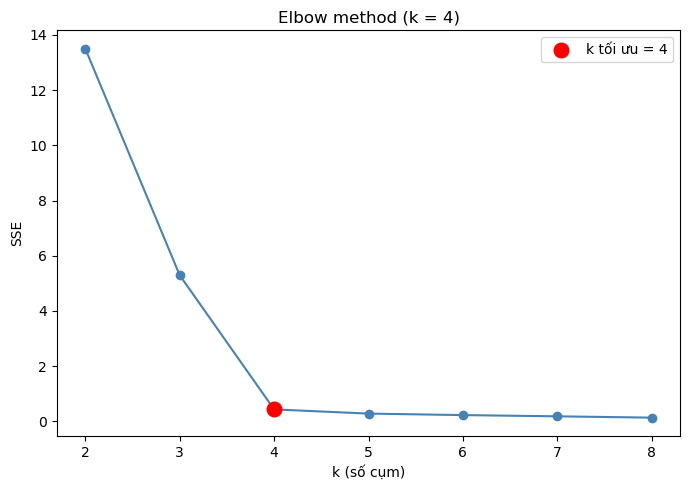

KMeans hội tụ sau 4 bước lặp


GMM-HMM hội tụ sau 23 vòng EM


In [63]:
# =======================================================
# HÌNH 2a: ELBOW METHOD (HARD-CODE k_opt = 4, chấm đỏ tại k=4)
# =======================================================
kv, sv = compute_sse_curve(sample_features, k_min=2, k_max=8)
k_opt = 4   # hard-code theo yêu cầu, không dùng choose_elbow_k nữa

sub_path_ranges = segment_sequence_round1(sample_features, k=k_opt)
states_info = {i: sample_features[s:e, :] for i, (s, e) in enumerate(sub_path_ranges)}
PALETTE = ["#00DDAA", "#FF5511", "#0000CD", "#FFA500", "#C0C0C0", "#FFD700"]

fig_elbow, ax_elbow = plt.subplots(figsize=(7, 5))
ax_elbow.plot(kv, sv, 'o-', color="steelblue")
idx_opt = kv.index(k_opt)
ax_elbow.scatter([k_opt], [sv[idx_opt]], color="red", s=110, zorder=5,
                 label=f"k tối ưu = {k_opt}")
ax_elbow.set_xlabel("k (số cụm)")
ax_elbow.set_ylabel("SSE")
ax_elbow.set_title("Elbow method (k = 4)")
ax_elbow.legend(loc="upper right")
plt.tight_layout()
plt.show()


# =======================================================
# HÌNH 2b: ANIMATION — KMEANS HỘI TỤ DẦN + TÂM (CENTROID) + COVARIANCE ELLIPSE
# (trình phát Play/Pause + thanh trượt)
# =======================================================
from matplotlib import animation
from matplotlib.patches import Ellipse
from IPython.display import HTML, display

def draw_cov_ellipse(ax, mean, cov, color, n_std=2.0, **kwargs):
    """Vẽ ellipse độ lệch chuẩn n_std quanh mean, dựa trên eigen-decomposition của cov."""
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, alpha=0.15, lw=2, **kwargs)
    ax.add_patch(ell)

pts = sample_features[:, :2]   # KMeans chỉ dùng (X, Y) như compute_sse_curve
n_pts = len(pts)

# --- Tự chạy Lloyd's algorithm (K-Means thủ công) để lưu lại lịch sử từng bước ---
rng = np.random.RandomState(RANDOM_STATE)
init_idx = rng.choice(n_pts, size=k_opt, replace=False)
centroids = pts[init_idx].copy()

history_labels = []
history_centroids = []
history_covs = []   # covariance thực nghiệm của từng cụm tại mỗi bước

max_iter = 30
prev_labels = None
for it in range(max_iter):
    dists = np.linalg.norm(pts[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(dists, axis=1)

    covs = []
    for c in range(k_opt):
        mask = labels == c
        if mask.sum() >= 3:
            covs.append(np.cov(pts[mask].T))
        else:
            covs.append(np.eye(2) * 1e-4)
    history_labels.append(labels.copy())
    history_centroids.append(centroids.copy())
    history_covs.append(covs)

    if prev_labels is not None and np.array_equal(labels, prev_labels):
        break
    prev_labels = labels

    new_centroids = centroids.copy()
    for c in range(k_opt):
        mask = labels == c
        if mask.any():
            new_centroids[c] = pts[mask].mean(axis=0)
    centroids = new_centroids

n_frames_km = len(history_labels)
print(f"KMeans hội tụ sau {n_frames_km} bước lặp")

fig_km, ax_km = plt.subplots(figsize=(7, 7))

def _update_kmeans(frame):
    ax_km.clear()
    labels = history_labels[frame]
    cents = history_centroids[frame]
    covs = history_covs[frame]
    for c in range(k_opt):
        mask = labels == c
        col = PALETTE[c % len(PALETTE)]
        ax_km.scatter(pts[mask, 0], pts[mask, 1], c=col, s=25, alpha=0.8, label=f"Cluster {c}")
        draw_cov_ellipse(ax_km, cents[c], covs[c], col, n_std=2.0)
    ax_km.scatter(cents[:, 0], cents[:, 1], c="black", marker="X", s=160,
                  edgecolors="white", linewidths=1.2, zorder=5, label="Centroid (tâm)")
    ax_km.set_xlabel("X(0~1)"); ax_km.set_ylabel("Y(0~1)")
    ax_km.set_xlim(-0.1, 1.1); ax_km.set_ylim(-0.1, 1.1)
    ax_km.set_title(f"KMeans hội tụ dần (k={k_opt}) — bước {frame+1}/{n_frames_km}\n"
                     f"(vòng tròn = covariance ellipse ±2σ quanh tâm)")
    ax_km.legend(loc="upper right", fontsize=8)
    return []

anim_kmeans = animation.FuncAnimation(fig_km, _update_kmeans, frames=n_frames_km,
                                       interval=800, blit=False, repeat=True)
plt.close(fig_km)
display(HTML(anim_kmeans.to_jshtml()))


# =======================================================
# HÌNH 2c: ANIMATION — GMM-HMM HỘI TỤ DẦN + TÂM (MEAN) + COVARIANCE ELLIPSOID
# fit trên (x, y, velocity), covariance_type='full', giống hệt segment_sequence_round1
# (trình phát Play/Pause + thanh trượt)
# =======================================================
from mpl_toolkits.mplot3d import art3d

def get_state_mean_cov(model, state):
    """Lấy mean/cov đại diện cho 1 state: nếu là GMMHMM (có mixture) thì lấy
    mixture có trọng số (weight) lớn nhất; nếu là GaussianHMM thì lấy thẳng."""
    if hasattr(model, "weights_"):
        best_mix = int(np.argmax(model.weights_[state]))
        mean = model.means_[state, best_mix]
        cov = model.covars_[state, best_mix]
    else:
        mean = model.means_[state]
        cov = model.covars_[state]
    return mean, cov

def draw_cov_ellipsoid(ax, mean, cov, color, n_std=1.5, n_points=14, alpha=0.15):
    """Vẽ ellipsoid 3D (wireframe) độ lệch chuẩn n_std quanh mean."""
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    radii = n_std * np.sqrt(vals)
    u = np.linspace(0, 2 * np.pi, n_points)
    v = np.linspace(0, np.pi, n_points)
    xs = radii[0] * np.outer(np.cos(u), np.sin(v))
    ys = radii[1] * np.outer(np.sin(u), np.sin(v))
    zs = radii[2] * np.outer(np.ones_like(u), np.cos(v))
    pts_stack = np.stack([xs, ys, zs], axis=-1)
    rotated = pts_stack @ vecs.T + mean
    ax.plot_wireframe(rotated[..., 0], rotated[..., 1], rotated[..., 2],
                       color=color, alpha=alpha, linewidth=0.6)
    ax.scatter([mean[0]], [mean[1]], [mean[2]], c=color, marker="X", s=140,
               edgecolors="black", linewidths=1.0, zorder=6)

def fit_gmmhmm_with_history(data, n_states, n_mix=2, covariance_type="full",
                             min_covar=1e-3, max_iter=50, tol=1e-3,
                             random_state=RANDOM_STATE):
    """Chạy EM từng bước 1 (n_iter=1 mỗi lần fit, warm-start), lưu lại
    Viterbi states + mean/cov + log-likelihood sau mỗi vòng lặp để animate
    quá trình hội tụ. Logic chọn GMMHMM/GaussianHMM mô phỏng lại
    build_and_fit_gmmhmm."""
    n_samples, n_dims = data.shape
    actual_mix = min(n_mix, max(1, n_samples // (n_states * 5)))
    use_gmm = actual_mix > 1

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            if use_gmm:
                model = GMMHMM(n_components=n_states, n_mix=actual_mix,
                                covariance_type=covariance_type, min_covar=min_covar,
                                n_iter=1, tol=tol, random_state=random_state,
                                init_params="stmcw")
            else:
                model = GaussianHMM(n_components=n_states, covariance_type=covariance_type,
                                     min_covar=min_covar, n_iter=1, tol=tol,
                                     random_state=random_state, init_params="stmc")

            history_states, history_ll = [], []
            history_means, history_covs_hmm = [], []
            prev_ll = None
            for it in range(max_iter):
                model.fit(data)            # 1 vòng EM (warm-start từ tham số hiện có)
                model.init_params = ""     # từ vòng 2 trở đi: không init lại ngẫu nhiên
                ll = model.score(data)
                _, states = model.decode(data, algorithm="viterbi")

                means_this_iter, covs_this_iter = {}, {}
                for st in np.unique(states):
                    m, c = get_state_mean_cov(model, int(st))
                    means_this_iter[int(st)] = m
                    covs_this_iter[int(st)] = c

                history_states.append(states.copy())
                history_ll.append(ll)
                history_means.append(means_this_iter)
                history_covs_hmm.append(covs_this_iter)

                if prev_ll is not None and abs(ll - prev_ll) < tol:
                    break
                prev_ll = ll
            return history_states, history_ll, history_means, history_covs_hmm
        except Exception as e:
            print("GMM-HMM lỗi, fallback về KMeans:", e)
            fallback = KMeans(n_clusters=n_states, n_init=5,
                               random_state=random_state).fit_predict(data)
            means_fb, covs_fb = {}, {}
            for st in np.unique(fallback):
                mask = fallback == st
                means_fb[int(st)] = data[mask].mean(axis=0)
                covs_fb[int(st)] = np.cov(data[mask].T) if mask.sum() >= 4 else np.eye(n_dims) * 1e-4
            return [fallback], [None], [means_fb], [covs_fb]

history_states_h2, history_ll_h2, history_means_h2, history_covs_h2 = fit_gmmhmm_with_history(
    sample_features, n_states=k_opt, n_mix=2, covariance_type="full", min_covar=1e-3
)
n_frames_hmm = len(history_states_h2)
print(f"GMM-HMM hội tụ sau {n_frames_hmm} vòng EM")

fig_hmm = plt.figure(figsize=(9, 7))
ax_hmm = fig_hmm.add_subplot(111, projection='3d')

def _update_gmmhmm(frame):
    ax_hmm.clear()
    states = history_states_h2[frame]
    means_f = history_means_h2[frame]
    covs_f = history_covs_h2[frame]
    for st in np.unique(states):
        mask = states == st
        c = PALETTE[int(st) % len(PALETTE)]
        ax_hmm.scatter(sample_features[mask, 0], sample_features[mask, 1], sample_features[mask, 2],
                        zdir="z", c=c, marker="o", s=40, depthshade=True, label=f"State {st}")
        if st in means_f:
            draw_cov_ellipsoid(ax_hmm, means_f[st], covs_f[st], c, n_std=1.5)

    ll = history_ll_h2[frame]
    ll_txt = f", log-likelihood={ll:.2f}" if ll is not None else ""
    ax_hmm.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
    ax_hmm.set_title(f"GMM-HMM hội tụ (k={k_opt}) — vòng EM {frame+1}/{n_frames_hmm}{ll_txt}\n"
                       f"(X = tâm state, lưới mờ = covariance ellipsoid ±1.5σ)", fontsize=11)
    ax_hmm.legend(loc="upper right")
    return []

anim_gmmhmm = animation.FuncAnimation(fig_hmm, _update_gmmhmm, frames=n_frames_hmm,
                                       interval=800, blit=False, repeat=True)
plt.close(fig_hmm)
display(HTML(anim_gmmhmm.to_jshtml()))

## Output cuối cùng của step 1

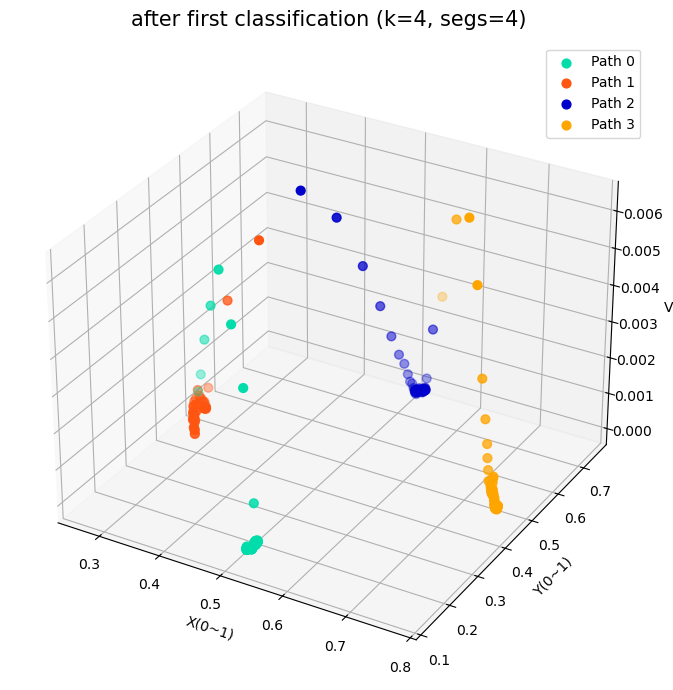

In [64]:
# =======================================================
# CELL 2: HÌNH 2 - PHÂN ĐOẠN ĐƯỜNG NHÌN (SUB-PATHS)
# =======================================================
kv, sv = compute_sse_curve(sample_features, k_min=2, k_max=8)
k_opt = choose_elbow_k(kv, sv)
sub_path_ranges = segment_sequence_round1(sample_features, k=k_opt)
states_info = {i: sample_features[s:e, :] for i, (s, e) in enumerate(sub_path_ranges)}

# Bảng mã màu chuẩn 100% từ dataplot.py
PALETTE = ["#00DDAA", "#FF5511", "#0000CD", "#FFA500", "#C0C0C0", "#FFD700"]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for key, section in states_info.items():
    c = PALETTE[key % len(PALETTE)]
    ax.scatter(section[:, 0], section[:, 1], section[:, 2], 
               zdir="z", c=c, marker="o", s=40, depthshade=True, label=f"Path {key}")

ax.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax.set_title(f"after first classification (k={k_opt}, segs={len(sub_path_ranges)})", fontsize=15, pad=12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 📌 Chú thích Step 2 — Chi tiết phân loại trong từng phân đoạn (Tầng 2, theo Vận tốc)

Với **mỗi sub-path** tìm được ở Hình 2, ta fit riêng 1 GMM-HMM 3 trạng thái chỉ trên cột **Vận tốc**
của đoạn đó, Viterbi-decode ra 3 "hành vi con" bên trong đoạn (ký hiệu bằng 3 marker chuẩn:
`x`, `^`, `.`), giữ nguyên màu theo từng Path như Hình 2. **Lưu ý:** đây là kết quả phân cụm nội
bộ (round-1) bên trong mỗi sub-path, **chưa phải nhãn cuối cùng** — nhãn 3 lớp chuẩn
(Fixation / Smooth Pursuit / Saccade) chỉ được xác định ở Hình 4.

Đây cũng là 1 vòng **lặp qua từng sub-path**, và bên trong mỗi sub-path lại là 1 vòng lặp EM để
GMM-HMM hội tụ 3 state con. Animation bên dưới thể hiện đầy đủ 2 cấp lặp đó:

- Lần lượt xử lý **từng sub-path** (Path 0, rồi Path 1, rồi Path 2, ...) — các đoạn chưa tới lượt
  hiển thị mờ màu xám.
- Với sub-path đang xử lý, hiện **từng vòng EM hội tụ**: state con được gán lại (re-assign) sau
  mỗi vòng, kèm **tâm (mean)** và **covariance ellipsoid ±1.5σ** của từng state con theo Vận tốc.
- Các sub-path đã xử lý xong giữ lại kết quả cuối (3 marker `x/^/.`) để đối chiếu.

Khung hình cuối cùng của animation (khi tất cả sub-path đã hội tụ) khớp với ảnh tĩnh gốc giữ
nguyên ở cell ngay bên dưới.

In [69]:
# =======================================================
# ANIMATION HÌNH 3: HỘI TỤ EM CHO TẤT CẢ SUB-PATH (LẦN LƯỢT TỪNG ĐOẠN)
# (tâm + covariance ellipsoid 3D — cùng phong cách với Hình 2c)
# =======================================================
from matplotlib import animation
from IPython.display import HTML, display

def fit_gmmhmm_with_history_generic(data, n_states, n_mix=2, covariance_type="full",
                                     min_covar=1e-3, max_iter=20, tol=1e-3,
                                     random_state=RANDOM_STATE):
    """Giống fit_gmmhmm_with_history ở Hình 2c, cho dữ liệu bất kỳ số chiều.
    Trả về lịch sử states + log-likelihood mỗi vòng EM."""
    n_samples, n_dims = data.shape
    if n_samples < n_states:
        return [np.zeros(n_samples, dtype=int)], [None]

    actual_mix = min(n_mix, max(1, n_samples // (n_states * 5)))
    use_gmm = actual_mix > 1

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            if use_gmm:
                model = GMMHMM(n_components=n_states, n_mix=actual_mix,
                                covariance_type=covariance_type, min_covar=min_covar,
                                n_iter=1, tol=tol, random_state=random_state,
                                init_params="stmcw")
            else:
                model = GaussianHMM(n_components=n_states, covariance_type=covariance_type,
                                     min_covar=min_covar, n_iter=1, tol=tol,
                                     random_state=random_state, init_params="stmc")
            history_states, history_ll = [], []
            prev_ll = None
            for it in range(max_iter):
                model.fit(data)
                model.init_params = ""
                ll = model.score(data)
                _, states = model.decode(data, algorithm="viterbi")
                history_states.append(states.copy())
                history_ll.append(ll)
                if prev_ll is not None and abs(ll - prev_ll) < tol:
                    break
                prev_ll = ll
            return history_states, history_ll
        except Exception:
            fallback = KMeans(n_clusters=n_states, n_init=5,
                               random_state=random_state).fit_predict(data)
            return [fallback], [None]

def draw_cov_ellipsoid(ax, mean, cov, color, n_std=1.5, n_points=12, alpha=0.15):
    """Y hệt hàm dùng ở Hình 2c: ellipsoid 3D (wireframe) ±n_std quanh mean."""
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    radii = n_std * np.sqrt(vals)
    u = np.linspace(0, 2 * np.pi, n_points)
    v = np.linspace(0, np.pi, n_points)
    xs = radii[0] * np.outer(np.cos(u), np.sin(v))
    ys = radii[1] * np.outer(np.sin(u), np.sin(v))
    zs = radii[2] * np.outer(np.ones_like(u), np.cos(v))
    pts_stack = np.stack([xs, ys, zs], axis=-1)
    rotated = pts_stack @ vecs.T + mean
    ax.plot_wireframe(rotated[..., 0], rotated[..., 1], rotated[..., 2],
                       color=color, alpha=alpha, linewidth=0.6)
    ax.scatter([mean[0]], [mean[1]], [mean[2]], c=color, marker="X", s=140,
               edgecolors="black", linewidths=1.0, zorder=6)

MARKER_BY_STATE = {0: "x", 1: "^", 2: "."}

def _scatter_segment_states(ax, section, states_arr, color, alpha=1.0, size=40):
    for st, marker in MARKER_BY_STATE.items():
        idx = np.where(states_arr == st)[0]
        if len(idx) > 0:
            ax.scatter(section[idx, 0], section[idx, 1], section[idx, 2],
                       zdir="z", c=color, marker=marker, s=size, alpha=alpha, depthshade=True)

n_seg3 = len(sub_path_ranges)

# --- Chạy trước lịch sử hội tụ EM cho TẤT CẢ sub-path (theo Vận tốc) ---
seg_history_states = []
seg_history_ll = []
seg_final_states = []
seg_sections = []
for key, (s, e) in enumerate(sub_path_ranges):
    section = sample_features[s:e, :]
    v_sub = section[:, 2].reshape(-1, 1)
    h_states, h_ll = fit_gmmhmm_with_history_generic(
        v_sub, n_states=3, n_mix=2, covariance_type="full", min_covar=1e-3
    )
    seg_history_states.append(h_states)
    seg_history_ll.append(h_ll)
    seg_final_states.append(h_states[-1])
    seg_sections.append(section)

gaze_states_info = {key: seg_final_states[key] for key in range(n_seg3)}  # dùng ở cell sau

# --- Ghép tất cả các bước EM của mọi segment thành 1 chuỗi frame duy nhất ---
frame_map = []  # (segment_key, local_iter_index)
for key in range(n_seg3):
    for li in range(len(seg_history_states[key])):
        frame_map.append((key, li))

total_frames_h3 = len(frame_map)
print(f"Tổng số frame (tất cả sub-path): {total_frames_h3}")

fig3 = plt.figure(figsize=(9, 7))
ax3 = fig3.add_subplot(111, projection='3d')

def _update_hinh3(frame):
    ax3.clear()
    cur_key, cur_li = frame_map[frame]

    # Các đoạn đã hội tụ xong (trước cur_key): vẽ kết quả cuối, không vẽ ellipsoid nữa
    for key in range(cur_key):
        c = PALETTE[key % len(PALETTE)]
        _scatter_segment_states(ax3, seg_sections[key], seg_final_states[key], c, alpha=0.85)

    # Đoạn đang xử lý: hiện state + tâm/covariance ellipsoid của vòng EM hiện tại
    section = seg_sections[cur_key]
    c = PALETTE[cur_key % len(PALETTE)]
    states_now = seg_history_states[cur_key][cur_li]
    _scatter_segment_states(ax3, section, states_now, c, alpha=1.0, size=55)

    for st in np.unique(states_now):
        mask = states_now == st
        if mask.sum() >= 4:
            mean_3d = section[mask].mean(axis=0)
            cov_3d = np.cov(section[mask].T)
            draw_cov_ellipsoid(ax3, mean_3d, cov_3d, c, n_std=1.5)

    # Các đoạn chưa tới lượt: mờ xám
    for key in range(cur_key + 1, n_seg3):
        sec = seg_sections[key]
        ax3.scatter(sec[:, 0], sec[:, 1], sec[:, 2],
                    zdir="z", c="lightgray", marker="o", s=15, alpha=0.4)

    n_iters_key = len(seg_history_states[cur_key])
    ll = seg_history_ll[cur_key][cur_li]
    ll_txt = f", log-likelihood={ll:.2f}" if ll is not None else ""
    ax3.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
    ax3.set_title(f"Sub-path {cur_key}/{n_seg3-1} — vòng EM {cur_li+1}/{n_iters_key}{ll_txt}\n"
                   f"(X = tâm state, lưới mờ = covariance ellipsoid ±1.5σ)", fontsize=11)
    return []

anim_hinh3 = animation.FuncAnimation(fig3, _update_hinh3, frames=total_frames_h3,
                                      interval=500, blit=False, repeat=True)
plt.close(fig3)
display(HTML(anim_hinh3.to_jshtml()))

Tổng số frame (tất cả sub-path): 80


## Kết quả cuối cùng step 2

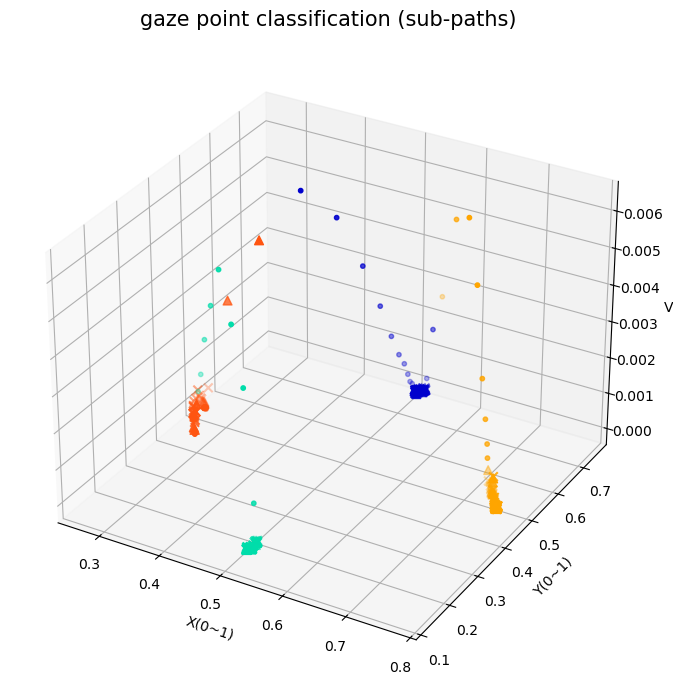

In [76]:
# =======================================================
# CELL 3: HÌNH 3 - CHI TIẾT TỪNG PHÂN ĐOẠN (MARKER CHUẨN GỐC)
# =======================================================
gaze_states_info = {}
for key, (s, e) in enumerate(sub_path_ranges):
    v_sub = sample_features[s:e, 2].reshape(-1, 1)
    raw_sub_states = build_and_fit_gmmhmm(v_sub, n_states=3, n_mix=2, covariance_type="full", min_covar=1e-3)
    gaze_states_info[key] = raw_sub_states

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Dùng đúng 3 marker x, ^, . theo từng cụm màu như dataplot.py
for key, (s, e) in enumerate(sub_path_ranges):
    section = sample_features[s:e, :]
    sub_labels = gaze_states_info[key]
    c = PALETTE[key % len(PALETTE)]
    
    # 0 -> 'x', 1 -> '^', 2 -> '.'
    idx_0 = np.where(sub_labels == 0)[0]
    idx_1 = np.where(sub_labels == 1)[0]
    idx_2 = np.where(sub_labels == 2)[0]
    
    if len(idx_0) > 0:
        ax.scatter(section[idx_0, 0], section[idx_0, 1], section[idx_0, 2], zdir="z", c=c, marker="x", s=40, depthshade=True)
    if len(idx_1) > 0:
        ax.scatter(section[idx_1, 0], section[idx_1, 1], section[idx_1, 2], zdir="z", c=c, marker="^", s=40, depthshade=True)
    if len(idx_2) > 0:
        ax.scatter(section[idx_2, 0], section[idx_2, 1], section[idx_2, 2], zdir="z", c=c, marker=".", s=40, depthshade=True)

ax.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax.set_title("gaze point classification (sub-paths)", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

# 📌 Chú thích Hình 4 — Kết quả dự đoán cuối cùng (Prediction, 3 lớp hành vi)

Từ ngưỡng vận tốc toàn cục (`thr_lo`, `thr_hi`) tính trên toàn file, mô hình phân loại lại từng
sub-path thành 3 lớp hành vi mắt chuẩn: **Fixation** (cố định, xanh lá `x`), **Smooth Pursuit**
(bám mượt, cam `^`), **Saccade** (giật, xanh dương `.`) — sau đó làm mượt nhãn bằng cửa sổ trượt
(majority voting, window=3) để loại nhiễu nhãn đơn lẻ.

Hình này chỉ hiển thị **kết quả cuối cùng**, không animate.


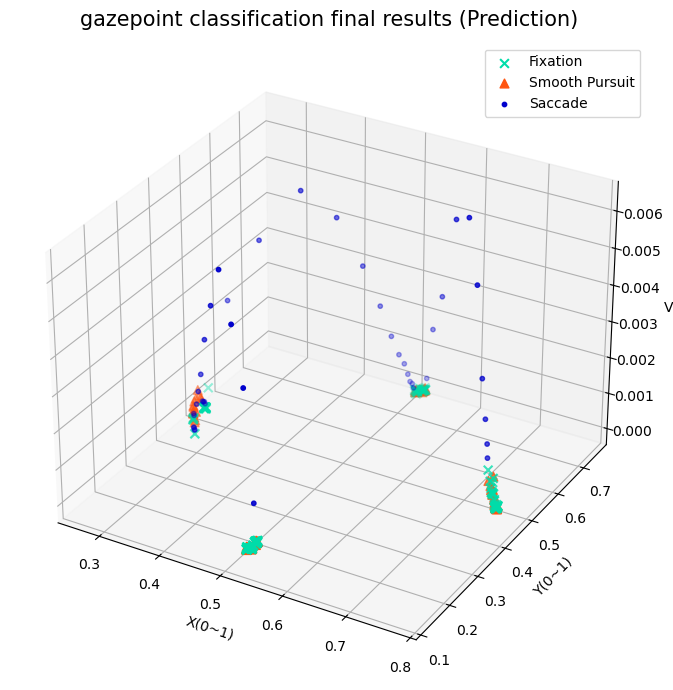

In [74]:
# =======================================================
# CELL 4: HÌNH 4 - KẾT QUẢ DỰ ĐOÁN (PREDICTION)
# =======================================================
velocities = sample_features[:, 2]
thr_lo, thr_hi = compute_velocity_thresholds(velocities)

final_pred = np.zeros(len(sample_features), dtype=int)
for s, e in sub_path_ranges:
    v_sub = velocities[s:e]
    final_pred[s:e] = classify_subpath_round2(v_sub, thr_lo, thr_hi)

final_pred = smooth_labels(final_pred, window=3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Phân tách đúng 3 nhóm theo định nghĩa màu & marker của repo gốc:
# Fixation: #00DDAA (marker 'x')
# Smooth Pursuit: #FF5511 (marker '^')
# Saccade: #0000CD (marker '.')
idx_fx = np.where(final_pred == 0)[0]
idx_sp = np.where(final_pred == 1)[0]
idx_sc = np.where(final_pred == 2)[0]

if len(idx_fx) > 0:
    ax.scatter(sample_features[idx_fx, 0], sample_features[idx_fx, 1], sample_features[idx_fx, 2], 
               zdir="z", c="#00DDAA", marker="x", s=40, depthshade=True, label="Fixation")
if len(idx_sp) > 0:
    ax.scatter(sample_features[idx_sp, 0], sample_features[idx_sp, 1], sample_features[idx_sp, 2], 
               zdir="z", c="#FF5511", marker="^", s=40, depthshade=True, label="Smooth Pursuit")
if len(idx_sc) > 0:
    ax.scatter(sample_features[idx_sc, 0], sample_features[idx_sc, 1], sample_features[idx_sc, 2], 
               zdir="z", c="#0000CD", marker=".", s=40, depthshade=True, label="Saccade")

ax.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax.set_title("gazepoint classification final results (Prediction)", fontsize=15, pad=12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 📌 Chú thích So Sánh Label VS Prediction

Accuracy trên file tester01_1.txt: 61.19%

                    precision    recall  f1-score   support

      Fixation (0)       0.90      0.62      0.73       277
Smooth Pursuit (1)       0.21      0.45      0.29        64
       Saccade (2)       0.60      0.87      0.71        30

          accuracy                           0.61       371
         macro avg       0.57      0.65      0.58       371
      weighted avg       0.75      0.61      0.66       371



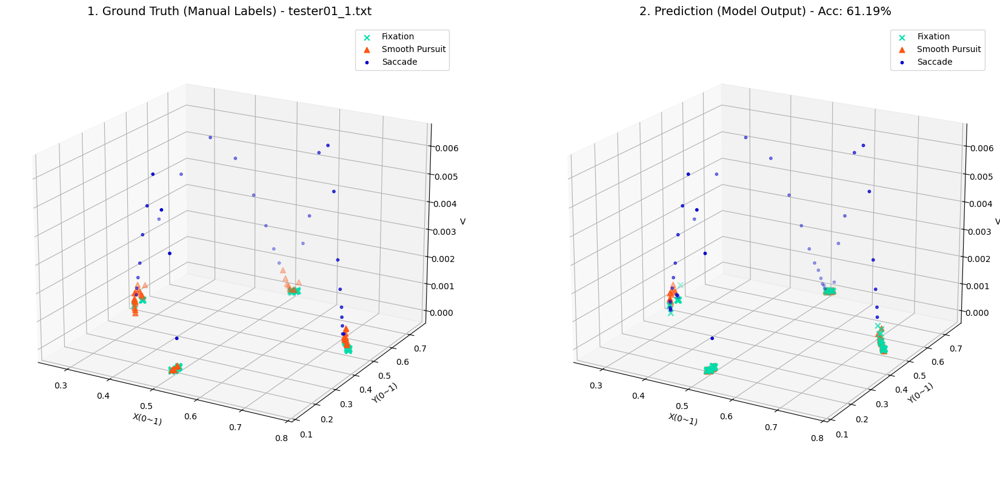

In [75]:
# =======================================================
# CELL 5: HÌNH 5 - SO SÁNH GROUND TRUTH (LABEL) VS PREDICTION
# =======================================================
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(sample_labels, final_pred)
print(f"Accuracy trên file {target_file.name}: {acc*100:.2f}%\n")
print(classification_report(sample_labels, final_pred, labels=[0, 1, 2], 
                            target_names=["Fixation (0)", "Smooth Pursuit (1)", "Saccade (2)"], zero_division=0))

# Tạo đồ thị 3D gồm 2 Subplots song song cùng góc nhìn để đối chiếu trực quan 1-1
fig = plt.figure(figsize=(18, 8))

# Subplot 1: Ground Truth (Manual Labels)
ax1 = fig.add_subplot(121, projection='3d')
for label_val, name, color, marker in [(0, "Fixation", "#00DDAA", "x"), 
                                       (1, "Smooth Pursuit", "#FF5511", "^"), 
                                       (2, "Saccade", "#0000CD", ".")]:
    idx = np.where(sample_labels == label_val)[0]
    if len(idx) > 0:
        ax1.scatter(sample_features[idx, 0], sample_features[idx, 1], sample_features[idx, 2],
                    zdir="z", c=color, marker=marker, s=40, depthshade=True, label=name)

ax1.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax1.set_title(f"1. Ground Truth (Manual Labels) - {target_file.name}", fontsize=14, pad=12)
ax1.legend(loc="upper right")

# Subplot 2: Prediction (Predicted Output)
ax2 = fig.add_subplot(122, projection='3d')
for label_val, name, color, marker in [(0, "Fixation", "#00DDAA", "x"), 
                                       (1, "Smooth Pursuit", "#FF5511", "^"), 
                                       (2, "Saccade", "#0000CD", ".")]:
    idx = np.where(final_pred == label_val)[0]
    if len(idx) > 0:
        ax2.scatter(sample_features[idx, 0], sample_features[idx, 1], sample_features[idx, 2],
                    zdir="z", c=color, marker=marker, s=40, depthshade=True, label=name)

ax2.set(xlabel="X(0~1)", ylabel="Y(0~1)", zlabel="V")
ax2.set_title(f"2. Prediction (Model Output) - Acc: {acc*100:.2f}%", fontsize=14, pad=12)
ax2.legend(loc="upper right")

# Đồng bộ góc nhìn 3D giữa 2 biểu đồ
ax1.view_init(elev=20, azim=-60)
ax2.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()